In [37]:
import pandas as pd 
import numpy as np 

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

In [2]:
# Define column names
col_names = ['unit_id', 'cycle', 'setting_1', 'setting_2', 'setting_3'] + \
            [f's_{i}' for i in range(1, 22)]

In [15]:
# Load FD001
df = pd.read_csv('../data/train_FD001.txt',
                 sep='\s+',
                 header=None,
                 index_col=False)

print("Number of columns detected:", df.shape[1])
print(df.head(2).to_string())

Number of columns detected: 26
   0   1       2       3      4       5       6        7        8      9      10      11       12       13   14     15      16       17       18      19    20   21    22     23     24       25
0   1   1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60  14.62  21.61  554.36  2388.06  9046.19  1.3  47.47  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0  39.06  23.4190
1   1   2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14  14.62  21.61  553.75  2388.04  9044.07  1.3  47.49  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0  39.00  23.4236


In [9]:
df.head()

unit_id   cycle  setting_1  setting_2  setting_3      s_1      s_2  \
1 1  -0.0007 -0.0004      100.0     518.67     641.82  1589.70  1400.60   
  2   0.0019 -0.0003      100.0     518.67     642.15  1591.82  1403.14   
  3  -0.0043  0.0003      100.0     518.67     642.35  1587.99  1404.20   
  4   0.0007  0.0000      100.0     518.67     642.35  1582.79  1401.87   
  5  -0.0019 -0.0002      100.0     518.67     642.37  1582.85  1406.22   

       s_3    s_4     s_5  ...     s_12    s_13  s_14  s_15  s_16   s_17  \
1 1  14.62  21.61  554.36  ...  8138.62  8.4195  0.03   392  2388  100.0   
  2  14.62  21.61  553.75  ...  8131.49  8.4318  0.03   392  2388  100.0   
  3  14.62  21.61  554.26  ...  8133.23  8.4178  0.03   390  2388  100.0   
  4  14.62  21.61  554.45  ...  8133.83  8.3682  0.03   392  2388  100.0   
  5  14.62  21.61  554.00  ...  8133.80  8.4294  0.03   393  2388  100.0   

      s_18     s_19  s_20  s_21  
1 1  39.06  23.4190   NaN   NaN  
  2  39.00  23.4236   NaN   NaN  
  3  38.95  23.3442   NaN   NaN  
  4  38.88  23.3739   NaN   NaN  
  5  38.90  23.4044   NaN   NaN  

[5 rows x 26 columns]

In [10]:
df.describe()

,unit_id,cycle,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
count,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,...,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000,0.0,0.0
mean,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,21.609803,553.367711,...,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705,NaN,NaN
std,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,0.001389,0.885092,...,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251,NaN,NaN
min,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,21.600000,549.850000,...,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200,NaN,NaN
25%,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,21.610000,552.810000,...,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800,NaN,NaN
50%,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,21.610000,553.440000,...,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900,NaN,NaN
75%,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,21.610000,554.010000,...,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800,NaN,NaN
max,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,21.610000,556.060000,...,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400,NaN,NaN


In [11]:
df.info()

<class 'pandas.DataFrame'>
MultiIndex: 20631 entries, (np.int64(1), np.int64(1)) to (np.int64(100), np.int64(200))
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   unit_id    20631 non-null  float64
 1   cycle      20631 non-null  float64
 2   setting_1  20631 non-null  float64
 3   setting_2  20631 non-null  float64
 4   setting_3  20631 non-null  float64
 5   s_1        20631 non-null  float64
 6   s_2        20631 non-null  float64
 7   s_3        20631 non-null  float64
 8   s_4        20631 non-null  float64
 9   s_5        20631 non-null  float64
 10  s_6        20631 non-null  float64
 11  s_7        20631 non-null  float64
 12  s_8        20631 non-null  float64
 13  s_9        20631 non-null  float64
 14  s_10       20631 non-null  float64
 15  s_11       20631 non-null  float64
 16  s_12       20631 non-null  float64
 17  s_13       20631 non-null  float64
 18  s_14       20631 non-null  float64
 19  s_15   

In [16]:
# 26 columns: unit_id, cycle, 3 settings, 21 sensors
col_names = ['unit_id', 'cycle', 'setting_1', 'setting_2', 'setting_3'] + \
            [f's_{i}' for i in range(1, 22)]

In [17]:
df.columns = col_names

# Verify
print(df.shape)
print(df.head(2).to_string())

(20631, 26)
   unit_id  cycle  setting_1  setting_2  setting_3     s_1     s_2      s_3      s_4    s_5    s_6     s_7      s_8      s_9  s_10   s_11    s_12     s_13     s_14    s_15  s_16  s_17  s_18   s_19   s_20     s_21
0        1      1    -0.0007    -0.0004      100.0  518.67  641.82  1589.70  1400.60  14.62  21.61  554.36  2388.06  9046.19   1.3  47.47  521.66  2388.02  8138.62  8.4195  0.03   392  2388  100.0  39.06  23.4190
1        1      2     0.0019    -0.0003      100.0  518.67  642.15  1591.82  1403.14  14.62  21.61  553.75  2388.04  9044.07   1.3  47.49  522.28  2388.07  8131.49  8.4318  0.03   392  2388  100.0  39.00  23.4236


In [14]:
print(df.columns.tolist())
print(df.head(2).to_string())

['unit_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10', 's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19']
     unit_id   cycle  setting_1  setting_2  setting_3      s_1      s_2    s_3    s_4     s_5      s_6      s_7  s_8    s_9    s_10     s_11     s_12    s_13  s_14  s_15  s_16   s_17   s_18     s_19
1 1  -0.0007 -0.0004      100.0     518.67     641.82  1589.70  1400.60  14.62  21.61  554.36  2388.06  9046.19  1.3  47.47  521.66  2388.02  8138.62  8.4195  0.03   392  2388  100.0  39.06  23.4190
  2   0.0019 -0.0003      100.0     518.67     642.15  1591.82  1403.14  14.62  21.61  553.75  2388.04  9044.07  1.3  47.49  522.28  2388.07  8131.49  8.4318  0.03   392  2388  100.0  39.00  23.4236


In [18]:
# Now check unique engines and max cycles
print("\nUnique engines:", df['unit_id'].nunique())
print("\nCycles per engine:")
print(df.groupby('unit_id')['cycle'].max().describe())


Unique engines: 100

Cycles per engine:
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


In [19]:
# For each engine, find its last cycle (= failure point)
max_cycles = df.groupby('unit_id')['cycle'].max().reset_index()
max_cycles.columns = ['unit_id', 'max_cycle']

In [20]:
# Merge back into df
df = df.merge(max_cycles, on='unit_id')

In [21]:
# RUL = how many cycles remain until failure
df['RUL'] = df['max_cycle'] - df['cycle']

# Drop max_cycle — no longer needed
df.drop('max_cycle', axis=1, inplace=True)

In [22]:
# Verify — first engine, first 5 rows
engine_1 = df[df['unit_id'] == 1].head(5)
print(engine_1[['unit_id', 'cycle', 'RUL']])

   unit_id  cycle  RUL
0        1      1  191
1        1      2  190
2        1      3  189
3        1      4  188
4        1      5  187


In [23]:
# Last 5 rows of engine 1 — RUL should reach 0
engine_1_end = df[df['unit_id'] == 1].tail(5)
print(engine_1_end[['unit_id', 'cycle', 'RUL']])

     unit_id  cycle  RUL
187        1    188    4
188        1    189    3
189        1    190    2
190        1    191    1
191        1    192    0


In [24]:
# Cap RUL at 125 — anything above means "healthy, not urgent"
df['RUL'] = df['RUL'].clip(upper=125)

# Verify
print(df['RUL'].describe())
print(df[df['unit_id'] == 1][['cycle', 'RUL']].head(10))

count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64
   cycle  RUL
0      1  125
1      2  125
2      3  125
3      4  125
4      5  125
5      6  125
6      7  125
7      8  125
8      9  125
9     10  125


## Feature Engineering

In [25]:
# We'll engineer rolling features over a window of 30 cycles
# For each engine separately — important, don't mix engines

window = 30

In [ ]:
# Select sensors that vary meaningfully — 
# some sensors in CMAPSS are constant, useless for prediction
# We'll identify and drop them first

sensor_cols = [f's_{i}' for i in range(1, 22)]

In [27]:
# Check standard deviation of each sensor
sensor_std = df[sensor_cols].std()
print(sensor_std.sort_values())

s_1     0.000000e+00
s_19    0.000000e+00
s_18    0.000000e+00
s_10    0.000000e+00
s_16    3.469531e-18
s_5     5.329200e-15
s_6     1.388985e-03
s_15    3.750504e-02
s_8     7.098548e-02
s_13    7.191892e-02
s_21    1.082509e-01
s_20    1.807464e-01
s_11    2.670874e-01
s_2     5.000533e-01
s_12    7.375534e-01
s_7     8.850923e-01
s_17    1.548763e+00
s_3     6.131150e+00
s_4     9.000605e+00
s_14    1.907618e+01
s_9     2.208288e+01
dtype: float64


In [28]:
# Drop sensors with near-zero std — they carry no information
useful_sensors = sensor_std[sensor_std > 0.1].index.tolist()
print("\nUseful sensors:", useful_sensors)


Useful sensors: ['s_2', 's_3', 's_4', 's_7', 's_9', 's_11', 's_12', 's_14', 's_17', 's_20', 's_21']


In [29]:
# Sort to ensure correct order per engine
df = df.sort_values(['unit_id', 'cycle']).reset_index(drop=True)

In [30]:
# For each useful sensor, compute rolling mean and std
# Group by engine so we don't bleed across engines
for sensor in useful_sensors:
    df[f'{sensor}_rmean'] = df.groupby('unit_id')[sensor] \
        .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
    df[f'{sensor}_rstd'] = df.groupby('unit_id')[sensor] \
        .transform(lambda x: x.rolling(window=window, min_periods=1).std().fillna(0))


In [31]:
# Check result
print(df.shape)
feature_cols = [f'{s}_rmean' for s in useful_sensors] + \
               [f'{s}_rstd' for s in useful_sensors]
print("Total features:", len(feature_cols))
print(df[feature_cols].head(3).to_string())

(20631, 49)
Total features: 22
    s_2_rmean    s_3_rmean    s_4_rmean   s_7_rmean    s_9_rmean  s_11_rmean  s_12_rmean   s_14_rmean  s_17_rmean  s_20_rmean  s_21_rmean  s_2_rstd  s_3_rstd  s_4_rstd  s_7_rstd  s_9_rstd  s_11_rstd  s_12_rstd  s_14_rstd  s_17_rstd  s_20_rstd  s_21_rstd
0  641.820000  1589.700000  1400.600000  554.360000  9046.190000       47.47      521.66  8138.620000  392.000000   39.060000     23.4190  0.000000  0.000000  0.000000  0.000000  0.000000   0.000000   0.000000   0.000000   0.000000   0.000000   0.000000
1  641.985000  1590.760000  1401.870000  554.055000  9045.130000       47.48      521.97  8135.055000  392.000000   39.030000     23.4213  0.233345  1.499066  1.796051  0.431335  1.499066   0.014142   0.438406   5.041671   0.000000   0.042426   0.003253
2  642.106667  1589.836667  1402.646667  554.123333  9047.733333       47.41      522.12  8134.446667  391.333333   39.003333     23.3956  0.267644  1.918654  1.850009  0.327159  4.632023   0.121655   0.4044

In [33]:
# Split by engine — 80% train, 20% test
train_engines = df['unit_id'].unique()[:80]
test_engines = df['unit_id'].unique()[80:]

train_df = df[df['unit_id'].isin(train_engines)]
test_df = df[df['unit_id'].isin(test_engines)]

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

Train rows: 16138
Test rows: 4493


In [34]:
# Features and target
X_train = train_df[feature_cols]
y_train = train_df['RUL']
X_test = test_df[feature_cols]
y_test = test_df['RUL']

In [35]:
# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
# Train
model = GradientBoostingRegressor(n_estimators=200, 
                                   max_depth=4, 
                                   learning_rate=0.05,
                                   random_state=42)
model.fit(X_train_scaled, y_train)
print("Training done")

Training done


## Evaluation

In [38]:
# Predict
y_pred = model.predict(X_test_scaled)

# Clip predictions — RUL can't be negative
y_pred = np.clip(y_pred, 0, 125)

In [39]:
# Standard metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = np.mean(np.abs(y_test - y_pred))
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")

RMSE: 19.51
MAE:  14.48


In [40]:
# Safety metric — how often do we underestimate RUL?
# (predict more life than actually remains — dangerous)
underestimates = np.sum(y_pred > y_test)
pct_dangerous = underestimates / len(y_test) * 100
print(f"\nDangerous predictions (underestimate urgency): {underestimates} ({pct_dangerous:.1f}%)")


Dangerous predictions (underestimate urgency): 1390 (30.9%)


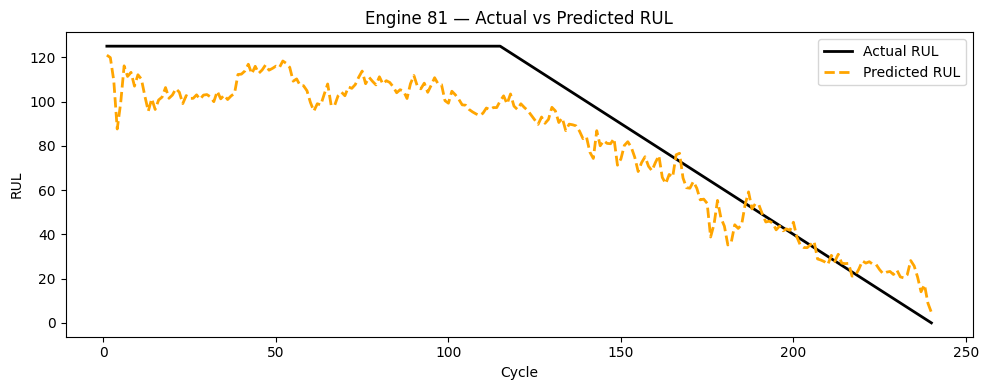

Plot saved


In [41]:
# Plot predicted vs actual for one engine
engine_id = test_engines[0]
engine_data = test_df[test_df['unit_id'] == engine_id].copy()
engine_data['predicted_RUL'] = model.predict(
    scaler.transform(engine_data[feature_cols])
)
engine_data['predicted_RUL'] = np.clip(engine_data['predicted_RUL'], 0, 125)

plt.figure(figsize=(10, 4))
plt.plot(engine_data['cycle'], engine_data['RUL'], 
         label='Actual RUL', color='black', linewidth=2)
plt.plot(engine_data['cycle'], engine_data['predicted_RUL'], 
         label='Predicted RUL', color='orange', linewidth=2, linestyle='--')
plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.title(f'Engine {engine_id} — Actual vs Predicted RUL')
plt.legend()
plt.tight_layout()
plt.savefig('../data/rul_prediction.png', dpi=150)
plt.show()
print("Plot saved")

In [42]:
# Among engines near end of life (RUL < 30), 
# how often do we dangerously overestimate?
critical = y_test < 30
critical_dangerous = np.sum(y_pred[critical] > y_test[critical])
print(f"Dangerous predictions when RUL < 30: "
      f"{critical_dangerous}/{critical.sum()} "
      f"({100*critical_dangerous/critical.sum():.1f}%)")

Dangerous predictions when RUL < 30: 374/600 (62.3%)
